In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [2]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extracted!")

Dataset extracted!


In [3]:
import os
print(os.listdir())

['.config', 'archive.zip', 'tungro', 'blast', 'blight', 'sample_data']


In [4]:
import os
import shutil

# Remove the existing 'dataset' directory to ensure a clean start
if os.path.exists("dataset"):
    shutil.rmtree("dataset")

# Create a fresh 'dataset' folder
os.makedirs("dataset")

# Move only valid class folders
for folder_name in ["blast", "blight", "tungro"]:
    source_path = folder_name
    destination_path = os.path.join("dataset", folder_name)

    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
    else:
        print(f"Warning: Source folder '{source_path}' not found. It might have been moved in a previous execution or does not exist.")

print("Clean dataset ready!")

Clean dataset ready!


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data = datagen.flow_from_directory(
    'dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    'dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 168 images belonging to 3 classes.
Found 72 images belonging to 3 classes.
{'blast': 0, 'blight': 1, 'tungro': 2}


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))  # ✅ FIX HERE

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3274 - loss: 2.9310 - val_accuracy: 0.3333 - val_loss: 1.0992
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 646ms/step - accuracy: 0.3571 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.1060
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 635ms/step - accuracy: 0.3333 - loss: 1.0890 - val_accuracy: 0.4167 - val_loss: 1.0758
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 758ms/step - accuracy: 0.5060 - loss: 1.0242 - val_accuracy: 0.4028 - val_loss: 1.0751
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 616ms/step - accuracy: 0.5893 - loss: 0.9440 - val_accuracy: 0.4722 - val_loss: 1.0651
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 639ms/step - accuracy: 0.5714 - loss: 0.9517 - val_accuracy: 0.5278 - val_loss: 1.0523
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 752ms/step - accuracy: 0.7202 - loss: 0.7471 - val_accuracy: 0.6528 - val_loss: 0.8534
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 651ms/step - accuracy: 0.7798 - loss: 0.5846 - val_accuracy: 0.6944 - val_loss: 0

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step


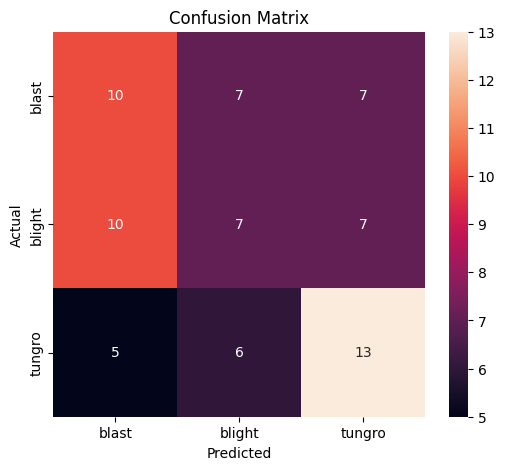

              precision    recall  f1-score   support

           0       0.40      0.42      0.41        24
           1       0.35      0.29      0.32        24
           2       0.48      0.54      0.51        24

    accuracy                           0.42        72
   macro avg       0.41      0.42      0.41        72
weighted avg       0.41      0.42      0.41        72



In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

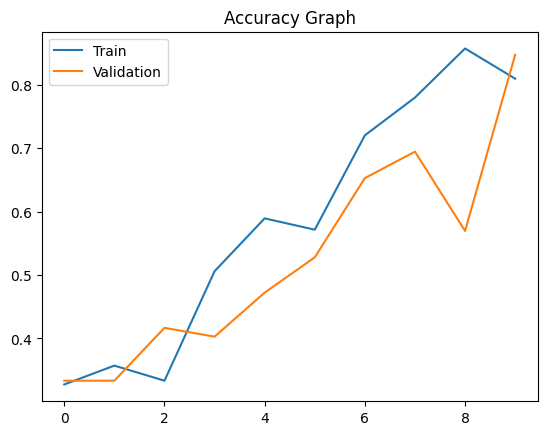

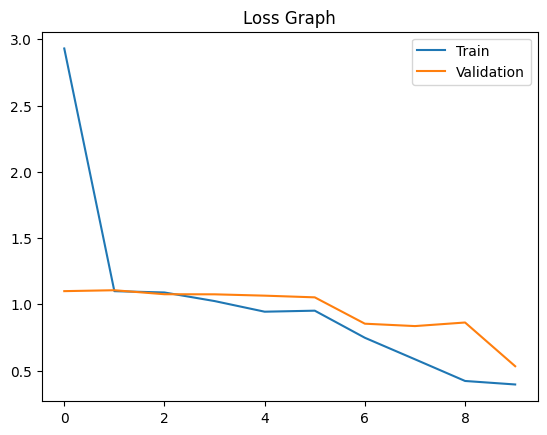

In [10]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss Graph")
plt.show()

Saving IMG_0414.jpg to IMG_0414.jpg


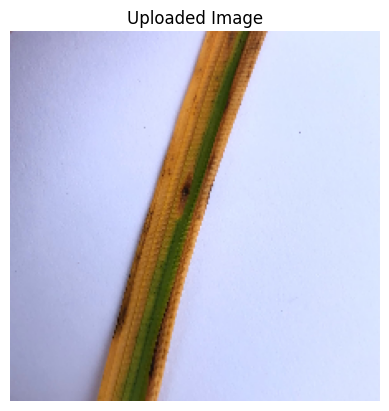

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
🌾 Rice Disease Detection Result
--------------------------------
Predicted Class : tungro
Confidence      : 75.97%
Model Accuracy  : 84.72%


In [12]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Upload Image
# -----------------------------
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# -----------------------------
# 2. Display Uploaded Image
# -----------------------------
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# -----------------------------
# 3. Preprocess Image
# -----------------------------
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# -----------------------------
# 4. Predict
# -----------------------------
prediction = model.predict(img_array)

# -----------------------------
# 5. Get Class Name
# -----------------------------
class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

# -----------------------------
# 6. Confidence
# -----------------------------
confidence = np.max(prediction) * 100

# -----------------------------
# 7. Model Accuracy
# -----------------------------
accuracy = history.history['val_accuracy'][-1] * 100

# -----------------------------
# 8. Final Output
# -----------------------------
print("🌾 Rice Disease Detection Result")
print("--------------------------------")
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")
print(f"Model Accuracy  : {accuracy:.2f}%")

In [13]:
train_acc = history.history['accuracy'][-1] * 100
val_acc = history.history['val_accuracy'][-1] * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")

Training Accuracy: 80.95%
Validation Accuracy: 84.72%
